In [1]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("torch built with cuda:", torch.cuda.is_available())
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Tue_Mar__8_18:18:20_PST_2022
Cuda compilation tools, release 11.6, V11.6.124
Build cuda_11.6.r11.6/compiler.31057947_0
torch:  1.13 ; cuda:  cu116
torch built with cuda: True
detectron2: 0.6


In [2]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common detectron2 utilities
from detectron2.config import get_cfg
from detectron2.structures import BoxMode
from detectron2.data import MetadataCatalog, DatasetCatalog, DatasetMapper
from detectron2.data import transforms as T
from detectron2.data import detection_utils, build_detection_train_loader
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.projects.point_rend import add_pointrend_config
from detectron2.utils.visualizer import Visualizer
from detectron2.evaluation import COCOEvaluator

# import some common libraries
import numpy as np
import os
import cv2
from PIL import Image
import pycocotools
from pycocotools import mask as coco_mask_util
import pickle
import copy
from typing import Dict

## Dataset
### Preparing the datasets
In the following, we read the train/test datasets and convert them to the lightweight dictionary format expected by the Detectron2 dataloader. Since this reading/parsing part takes a while, we save the results to disk and load them from disk in the function used for loading our custom datasets. 

Run the following cells only once for any new dataset to use. Jump to "Registering the datasets" step.

In [ ]:
def parse_cell_mask_dataset(images_path: str, 
                            masks_path: str, 
                            percentage_to_expand_bbox_boundaries: float=0.0, 
                            annots_in_coco_rle_format: bool=True):
    
    # list of images and mask annotation files
    # image_xyz.jpg in the images_path folder should have a corresponding annotation file
    # with the same name and npz format, image_xyz.npz in masks_path folder
    img_filenames = list(sorted(os.listdir(images_path)))
    mask_filenames = list(sorted(os.listdir(masks_path)))
    
    dataset_dicts: list[dict] = []
    # going though the images
    for idx, img_filename in enumerate(img_filenames):
        
        # a dictionary to record the annotations for the image under consideration
        record: dict = {}
        
        # drop the image filename extensio, the mask filename should have the same
        # name as the image with either 'npz' or 'pkl' as the extension
        # (anything after the last '.' in the filename is considered as extension)
        img_name = ".".join(img_filename.strip().split('.')[:-1])
    
        # load the image
        img_path = os.path.join(images_path, img_filename)
        
        # read the image, these images are pre-processed in grayscale with bit-depth = 8
        # no further scaling is needed here
        img = Image.open(img_path)
        image_width, image_height = img.size
        
        if annots_in_coco_rle_format:
            # annotations are in COCO RLE format
            
            boxes: List[List[int]] = []
            labels: List[int] = []
            masks: List[np.ndarray] = []
            
            # load the annotations (pickled when annots_in_coco_rle_format is True)
            mask_filename = img_name + '.pkl'
            if mask_filename not in mask_filenames:
                # skip if the annotation does not exist
                continue
            
            mask_path = os.path.join(masks_path, mask_filename)
            filehandler = open(mask_path, 'rb')
            annots = pickle.load(filehandler)
            filehandler.close()
            
            for sample in annots['annotations']:
                xmin, ymin, xmax, ymax = sample['bbox']
                # no need to check the validity 
                if xmin >= xmax or ymin >= ymax:
                    continue
                
                labels.append(int(sample['category_id']))
                mask: np.ndarray = coco_mask_util.decode(sample['segmentation'])
                # mask in full image resolution
                full_res_mask: np.ndarray = np.zeros((image_height, image_width), np.uint8)
                full_res_mask[ymin:ymax, xmin:xmax] = mask
                
                masks.append(full_res_mask)
                
                # expand the bounding box if needed
                delta_x = int(percentage_to_expand_bbox_boundaries * (xmax - xmin) / 2)
                delta_y = int(percentage_to_expand_bbox_boundaries * (ymax - ymin) / 2)
            
                delta_x = max(1, delta_x)
                delta_y = max(1, delta_y)
            
                xmin = max(0, xmin - delta_x)
                ymin = max(0, ymin - delta_y)
                xmax = min(image_width, xmax + delta_x)
                ymax = min(image_height, ymax + delta_y)
                
                boxes.append([xmin, ymin, xmax, ymax])
                
            num_objs = len(boxes)
            # combine all the masks
            masks = np.array(masks)
            labels = np.array(labels)
        else:
            # loaded_mask is a m x image_height x image_width array (the same size as the input image)
            # the assumption here is instances are encoded as different levels
            # with 0 being the background
            # each element in mask is an np.uint16 (unsigned 16 bits)
            # to support overlapping objects, objects with overlaps are reported in 
            # different arrays (loaded_mask[i])
            # so we simply need to extract masks from all these arrays
            mask_filename = img_name + '.npz'
            if mask_filename not in mask_filenames:
                continue
            
            mask_path = os.path.join(masks_path, mask_filename)
            loaded = np.load(mask_path)
            loaded_masks = loaded['saved_masks']
            loaded_labels = loaded['saved_labels']
        
            num_objs = 0
            labels: List[int] = []
            masks: List[np.ndarray] = []
            
            for i in range(loaded_masks.shape[0]):
                # instances are encoded as different gray levels
                # the results are sorted
                # first id [0] is the background, so remove it
                obj_ids = np.unique(loaded_masks[i])[1:]
        
                num_objs += len(obj_ids)
        
                # split the color-encoded mask into a set
                # of binary masks
                masks.append((loaded_masks[i] == obj_ids[:, None, None]).astype(np.uint8))
                # make sure labels are mapped correctly to masks
                labels += list(loaded_labels[obj_ids - 1])
        
            # combine all the masks
            masks = np.concatenate(masks, axis=0)
            labels = np.array(labels)
        
            # get bounding box coordinates for each mask
            boxes: List[List[int]] = []
            valid_ids = []
            for i in range(num_objs):
                pos = np.where(masks[i])
                xmin = np.min(pos[1])
                xmax = np.max(pos[1])
                ymin = np.min(pos[0])
                ymax = np.max(pos[0])
            
                if xmin >= xmax or ymin >= ymax:
                    continue
            
                delta_x = int(percentage_to_expand_bbox_boundaries * (xmax - xmin) / 2)
                delta_y = int(percentage_to_expand_bbox_boundaries * (ymax - ymin) / 2)
            
                delta_x = max(1, delta_x)
                delta_y = max(1, delta_y)
            
                xmin = max(0, xmin - delta_x)
                ymin = max(0, ymin - delta_y)
                xmax = min(image_width, xmax + delta_x)
                ymax = min(image_height, ymax + delta_y)
            
                valid_ids.append(i)
                boxes.append([xmin, ymin, xmax, ymax])
        
            num_objs = len(valid_ids)
            labels = labels[valid_ids]
            masks = masks[valid_ids]
        
        record['file_name'] = img_path
        record['image_id'] = idx
        record['height'] = image_height
        record['width'] = image_width 
        record['annotations']: List[dict] = []
        # going through the annotated objects in the image under consideration
        for i in range(num_objs):
            annots: dict = {'bbox': [boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]],
                            'bbox_mode': BoxMode.XYXY_ABS,
                            'category_id' : int(labels[i] - 1), # labels start from 0 in Detectron
                            'segmentation': coco_mask_util.encode(np.asarray(masks[i], order="F")),
                             'iscrowd': 0
                           } 
                        # cfg.INPUT.MASK_FORMAT must be set to bitmask if using the default data loader 
                        # with dict 'segmentation mask above'.

            record['annotations'].append(annots)
        # end for
        dataset_dicts.append(record)
    # end for
    return dataset_dicts

#### Reading the datasets
This will take a while. 

In [ ]:
# make sure each folder includes both 'train' and 'test' sub-folders containing the images
# and masks for the train/test sets
IMAGES_FOLDER = '/home/cellareye/Cellanome/dl-mehdi/Mask RCNN/data/analysis_data_cells_set_2_crop_2/images/'
MASKS_FOLDER = '/home/cellareye/Cellanome/dl-mehdi/Mask RCNN/data/analysis_data_cells_set_2_crop_2/masks/'

import time
start = time.time()
dataset_type = 'test'
dataset_dicts_test = parse_cell_mask_dataset(images_path = IMAGES_FOLDER + dataset_type, 
                                             masks_path = MASKS_FOLDER + dataset_type, 
                                             percentage_to_expand_bbox_boundaries=0.0, 
                                             annots_in_coco_rle_format=True)


print("Reading test dataset took: ", time.time() - start)

start = time.time()
dataset_type = 'train'
dataset_dicts_train = parse_cell_mask_dataset(images_path = IMAGES_FOLDER + dataset_type, 
                                              masks_path = MASKS_FOLDER + dataset_type, 
                                              percentage_to_expand_bbox_boundaries=0.0, 
                                              annots_in_coco_rle_format=True)
print("Reading train dataset took: ", time.time() - start)

#### Saving the datasets to disk

In [ ]:
filehandler = open('data/test_data.pkl', 'wb')
pickle.dump(dataset_dicts_test, filehandler)
filehandler.close()

filehandler = open('data/train_data.pkl', 'wb')
pickle.dump(dataset_dicts_train, filehandler)
filehandler.close()

### Registering the datasets
The following custom dataset reader function only loads the already processed data from disk. 

In [3]:
def get_cell_mask_dataset(dataset_type: str):
    if dataset_type == 'train':
        filehandler = open('data/train_data.pkl', 'rb')
    elif dataset_type == 'test':
        filehandler = open('data/test_data.pkl', 'rb')
    else:
        return []
    
    dataset_dicts = pickle.load(filehandler)
    filehandler.close()
    return dataset_dicts

In [4]:
for dataset_type in ['train', 'test']:
    DatasetCatalog.register('analysis_data_cells_set_2_crop_2_' + dataset_type, 
                            lambda dataset_type=dataset_type: get_cell_mask_dataset(dataset_type))
    
    MetadataCatalog.get('analysis_data_cells_set_2_crop_2_' + dataset_type).set(thing_classes=['cell', 'bead', 'cage'])
    MetadataCatalog.get('analysis_data_cells_set_2_crop_2_' + dataset_type).set(evaluator_type='coco')


## Model Definition
We use the PointRend model with ResNet50 + FPN from Detectron2 that has been trained on COCO dataset (80 classes) as the starting point and modify its head. 

In [5]:
# get detectron2's default config
cfg = get_cfg()
# add PointRend-specific default config
add_pointrend_config(cfg)
# load the RCNN ResNet50 + FPN PointRend model config from file
cfg.merge_from_file("/home/cellareye/Development/detectron2/projects/PointRend/configs/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco.yaml")
# this threshold is needed for inference
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model

# use a model from PointRend model zoo: https://github.com/facebookresearch/detectron2/tree/master/projects/PointRend#pretrained-models
cfg.MODEL.WEIGHTS = "detectron2://PointRend/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco/164955410/model_final_edd263.pkl"
# the "RoIHead batch size" (default: 512)
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 1024   
#  NOTE: this is the number of classes, num_classes and not num_classes+1
cfg.MODEL.POINT_HEAD.NUM_CLASSES = 3
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
# already set correctly
# cfg.INPUT.MASK_FORMAT = 'bitmask'

## Training
### Datasets

In [6]:
cfg.DATASETS.TRAIN = ('analysis_data_cells_set_2_crop_2_train',)
cfg.DATASETS.TEST = ('analysis_data_cells_set_2_crop_2_test',)
# evaluation period (number of iterations)
cfg.TEST.EVAL_PERIOD = 10000
cfg.DATALOADER.NUM_WORKERS = 32

### Check some samples

In [7]:
def show_sample(idx, train=True, mapper=None):
    if train:
        dataset_type = 'train'
        registered_dataset = cfg.DATASETS.TRAIN[0]
    else:
        dataset_type = 'test'
        registered_dataset = cfg.DATASETS.TEST[0]

    dataset_dicts = get_cell_mask_dataset(dataset_type)
    analysis_data_cells_metadata = MetadataCatalog.get(registered_dataset)
    
    sample = dataset_dicts[idx]
    if mapper is None: 
        img = cv2.imread(sample['file_name'])
        visualizer = Visualizer(img[:, :, ::-1], metadata=analysis_data_cells_metadata, scale=0.5)
        out = visualizer.draw_dataset_dict(sample)
    else:
        transformed_sample = mapper(sample)
        img = np.array(transformed_sample["image"]).transpose((1, 2, 0))
        visualizer = Visualizer(img[:, :, ::-1], metadata=analysis_data_cells_metadata, scale=0.5)
        out = visualizer.overlay_instances(
            boxes=transformed_sample["instances"].gt_boxes, 
            masks=transformed_sample["instances"].gt_masks, 
            labels=[analysis_data_cells_metadata.thing_classes[i - 1] for i in 
                    np.array(transformed_sample["instances"].gt_classes)])

    display(Image.fromarray(out.get_image()[:, :, ::-1]))

/home/cellareye/python-envs/Detectron/lib/python3.8/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/cellareye/python-envs/Detectron/lib/python3.8/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


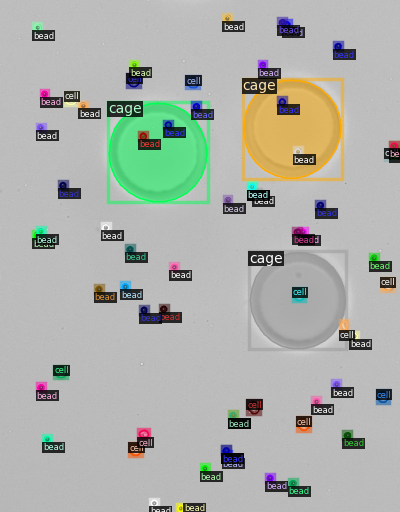

In [8]:
show_sample(idx=40, train=False)

### Augmentations
For now, we are using mainly random resizing (0.8-1).

In [9]:
AUGMENTATIONS = [
        T.RandomBrightness(0.9, 1.1),
        T.RandomFlip(prob=0.5),
        T.RandomResize([(819, 640), (870, 680), (921, 720), (972, 760), (1024, 800)])
    ]

#### Check the sample after transformation

In [10]:
# we are using the below mapper for displaying augmented samples, later we define it in the training class
mapper = DatasetMapper(cfg, is_train=True, augmentations=AUGMENTATIONS)

[02/23 10:49:31 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: [RandomBrightness(intensity_min=0.9, intensity_max=1.1), RandomFlip(prob=0.5), RandomResize(shape_list=[(819, 640), (870, 680), (921, 720), (972, 760), (1024, 800)])]


/home/cellareye/python-envs/Detectron/lib/python3.8/site-packages/detectron2/data/detection_utils.py:446: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:199.)
  torch.stack([torch.from_numpy(np.ascontiguousarray(x)) for x in masks])


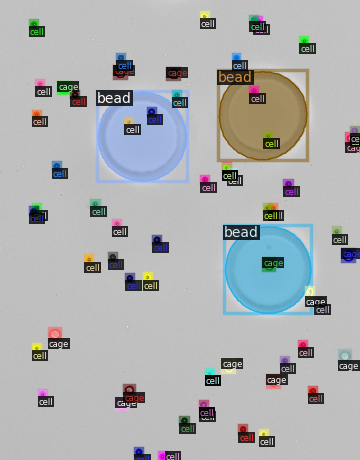

In [11]:
show_sample(idx=40, train=False, mapper=mapper)

### Training parameters

In [12]:
# this is the batch size 
cfg.SOLVER.IMS_PER_BATCH = 2  
cfg.SOLVER.BASE_LR = 0.001  # initial Learning rate
cfg.SOLVER.MAX_ITER = 50000 # number of iterations
cfg.SOLVER.STEPS = [10000, 30000, 40000] # steps      
cfg.freeze()

### Customized Trainer class

In [13]:
class Trainer(DefaultTrainer):
    """
    We use the "DefaultTrainer" which contains a number pre-defined logic for
    standard training workflow. They may not work for you, especially if you
    are working on a new research project. In that case you can use the cleaner
    "SimpleTrainer", or write your own training loop.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each builtin dataset.
        For your own dataset, you can simply create an evaluator manually in your
        script and do not have to worry about the hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference", dataset_name)
        
        return COCOEvaluator(dataset_name, 
                             tasks = ['bbox', 'segm'], 
                             max_dets_per_image = 1000, 
                             output_dir=output_folder)
    
    @classmethod
    def build_train_loader(cls, cfg):
        mapper = DatasetMapper(cfg, is_train=True, augmentations=[])
        return build_detection_train_loader(cfg, mapper=mapper)
    

### Run training for the specific number of iterations

In [14]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = Trainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[02/23 10:51:32 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

[02/23 10:51:32 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: []
[02/23 10:51:36 d2.data.build]: Removed 0 images with no usable annotations. 17710 images left.
[02/23 10:51:36 d2.data.build]: Using training sampler TrainingSampler
[02/23 10:51:36 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[02/23 10:51:36 d2.data.common]: Serializing 17710 elements to byte tensors and concatenating them all ...
[02/23 10:51:41 d2.data.common]: Serialized dataset takes 199.10 MiB
[02/23 10:51:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from detectron2://PointRend/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco/164955410/model_final_edd263.pkl ...
WARNING [02/23 10:51:41 d2.projects.point_rend.mask_head]: Weight format of PointRend models have changed! Applying automatic conversion now ...


Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (12, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (12,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.coarse_head.prediction.weight' to the model due to incompatible shapes: (3920, 1024) in the checkpoint but (147,

[02/23 10:51:41 d2.engine.train_loop]: Starting training from iteration 0


/home/cellareye/python-envs/Detectron/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


...

[02/23 14:03:04 d2.utils.events]:  eta: 0:06:13  iter: 48199  total_loss: 0.7332  loss_cls: 0.03945  loss_box_reg: 0.1086  loss_mask: 0.1271  loss_mask_point: 0.3656  loss_rpn_cls: 0.00727  loss_rpn_loc: 0.05795  time: 0.2102  data_time: 0.0097  lr: 1e-06  max_mem: 7391M
[02/23 14:03:08 d2.utils.events]:  eta: 0:06:09  iter: 48219  total_loss: 0.7146  loss_cls: 0.03686  loss_box_reg: 0.1144  loss_mask: 0.1425  loss_mask_point: 0.3613  loss_rpn_cls: 0.003411  loss_rpn_loc: 0.05144  time: 0.2102  data_time: 0.0107  lr: 1e-06  max_mem: 7391M
[02/23 14:03:12 d2.utils.events]:  eta: 0:06:04  iter: 48239  total_loss: 0.6722  loss_cls: 0.0407  loss_box_reg: 0.1077  loss_mask: 0.1295  loss_mask_point: 0.3556  loss_rpn_cls: 0.004181  loss_rpn_loc: 0.04391  time: 0.2102  data_time: 0.0110  lr: 1e-06  max_mem: 7391M
[02/23 14:03:17 d2.utils.events]:  eta: 0:06:00  iter: 48259  total_loss: 0.7164  loss_cls: 0.04247  loss_box_reg: 0.1249  loss_mask: 0.1362  loss_mask_point: 0.3634  loss_rpn_cls: 0.

[02/23 14:05:10 d2.utils.events]:  eta: 0:04:08  iter: 48799  total_loss: 0.8036  loss_cls: 0.05526  loss_box_reg: 0.1308  loss_mask: 0.1399  loss_mask_point: 0.3872  loss_rpn_cls: 0.006677  loss_rpn_loc: 0.05707  time: 0.2102  data_time: 0.0127  lr: 1e-06  max_mem: 7391M
[02/23 14:05:14 d2.utils.events]:  eta: 0:04:04  iter: 48819  total_loss: 0.744  loss_cls: 0.04897  loss_box_reg: 0.1226  loss_mask: 0.1389  loss_mask_point: 0.3684  loss_rpn_cls: 0.002936  loss_rpn_loc: 0.04886  time: 0.2102  data_time: 0.0130  lr: 1e-06  max_mem: 7391M
[02/23 14:05:18 d2.utils.events]:  eta: 0:04:00  iter: 48839  total_loss: 0.7557  loss_cls: 0.03541  loss_box_reg: 0.1078  loss_mask: 0.1399  loss_mask_point: 0.3699  loss_rpn_cls: 0.008487  loss_rpn_loc: 0.05018  time: 0.2102  data_time: 0.0119  lr: 1e-06  max_mem: 7391M
[02/23 14:05:23 d2.utils.events]:  eta: 0:03:56  iter: 48859  total_loss: 0.7942  loss_cls: 0.04914  loss_box_reg: 0.1265  loss_mask: 0.1461  loss_mask_point: 0.3891  loss_rpn_cls: 0

[02/23 14:07:16 d2.utils.events]:  eta: 0:02:04  iter: 49399  total_loss: 0.8022  loss_cls: 0.04496  loss_box_reg: 0.1277  loss_mask: 0.1347  loss_mask_point: 0.3664  loss_rpn_cls: 0.01882  loss_rpn_loc: 0.06187  time: 0.2102  data_time: 0.0133  lr: 1e-06  max_mem: 7391M
[02/23 14:07:20 d2.utils.events]:  eta: 0:02:00  iter: 49419  total_loss: 0.7265  loss_cls: 0.04569  loss_box_reg: 0.113  loss_mask: 0.1415  loss_mask_point: 0.3649  loss_rpn_cls: 0.01151  loss_rpn_loc: 0.05285  time: 0.2102  data_time: 0.0148  lr: 1e-06  max_mem: 7391M
[02/23 14:07:24 d2.utils.events]:  eta: 0:01:56  iter: 49439  total_loss: 0.822  loss_cls: 0.05591  loss_box_reg: 0.1297  loss_mask: 0.1483  loss_mask_point: 0.3815  loss_rpn_cls: 0.005841  loss_rpn_loc: 0.07083  time: 0.2102  data_time: 0.0122  lr: 1e-06  max_mem: 7391M
[02/23 14:07:28 d2.utils.events]:  eta: 0:01:52  iter: 49459  total_loss: 0.7534  loss_cls: 0.05073  loss_box_reg: 0.1275  loss_mask: 0.1468  loss_mask_point: 0.38  loss_rpn_cls: 0.0077

[02/23 14:09:20 d2.utils.events]:  eta: 0:00:00  iter: 49999  total_loss: 0.722  loss_cls: 0.04387  loss_box_reg: 0.1188  loss_mask: 0.1354  loss_mask_point: 0.3711  loss_rpn_cls: 0.01186  loss_rpn_loc: 0.05306  time: 0.2101  data_time: 0.0112  lr: 1e-06  max_mem: 7391M
[02/23 14:09:20 d2.engine.hooks]: Overall training speed: 49998 iterations in 2:55:04 (0.2101 s / it)
[02/23 14:09:20 d2.engine.hooks]: Total training time: 3:17:34 (0:22:29 on hooks)
[02/23 14:09:20 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[02/23 14:09:20 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[02/23 14:09:20 d2.data.common]: Serializing 2028 elements to byte tensors and concatenating them all ...
[02/23 14:09:21 d2.data.common]: Serialized dataset takes 22.90 MiB
[02/23 14:09:21 d2.evaluation.evaluator]: Start inference on 2028 batches


Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=73.47s).
Accumulating evaluation results...
DONE (t=0.46s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.692
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.834
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.795
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.451
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.558
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.954
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.399
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.724
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | ma

In [ ]:
"""
Evaluate annotation type *bbox*
DONE (t=81.35s).
Accumulating evaluation results...
DONE (t=0.64s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.670
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.830
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.774
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.431
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.590
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.957
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.408
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.702
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.469
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.672
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.973
[02/08 21:22:12 d2.evaluation.coco_evaluation]: Evaluation results for bbox: 
|   AP   |  AP50  |  AP75  |  APs   |  APm   |  APl   |
|:------:|:------:|:------:|:------:|:------:|:------:|
| 67.008 | 83.009 | 77.401 | 43.148 | 58.976 | 95.685 |
[02/08 21:22:12 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category   | AP     | category   | AP     | category   | AP     |
|:-----------|:-------|:-----------|:-------|:-----------|:-------|
| cell       | 56.246 | bead       | 51.244 | cage       | 93.534 |

Evaluate annotation type *segm*
DONE (t=82.19s).
Accumulating evaluation results...
DONE (t=0.65s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.677
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.830
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.775
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.442
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.634
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.956
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.091
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.409
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.707
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.479
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.670
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.973
[02/08 21:23:37 d2.evaluation.coco_evaluation]: Evaluation results for segm: 
|   AP   |  AP50  |  AP75  |  APs   |  APm   |  APl   |
|:------:|:------:|:------:|:------:|:------:|:------:|
| 67.730 | 83.010 | 77.490 | 44.184 | 63.395 | 95.576 |
[02/08 21:23:37 d2.evaluation.coco_evaluation]: Per-category segm AP: 
| category   | AP     | category   | AP     | category   | AP     |
|:-----------|:-------|:-----------|:-------|:-----------|:-------|
| cell       | 56.867 | bead       | 52.611 | cage       | 93.711 |
"""

### Test set evaluation (COCO metrics)

In [ ]:
from collections import OrderedDict
import detectron2.utils.comm as comm
from tools.plain_train_net import build_model, build_detection_test_loader, inference_on_dataset, print_csv_format
import logging
logger = logging.getLogger("detectron2")

In [ ]:
def do_evaluate(cfg, model):
    results = OrderedDict()
    for dataset_name in cfg.DATASETS.TEST:
        data_loader = build_detection_test_loader(cfg, dataset_name)

        evaluator = COCOEvaluator(dataset_name, 
                                  tasks = ['bbox', 'segm'], 
                                  max_dets_per_image = 1000, 
                                  output_dir=os.path.join(cfg.OUTPUT_DIR, "inference", dataset_name))  
        results_i = inference_on_dataset(model, data_loader, evaluator)
        results[dataset_name] = results_i
        if comm.is_main_process():
            logger.info("Evaluation results for {} in csv format:".format(dataset_name))
            print_csv_format(results_i)
    if len(results) == 1:
        results = list(results.values())[0]
    return results

In [ ]:
# get detectron2's default config
cfg = get_cfg()
# add PointRend-specific default config
add_pointrend_config(cfg)
# load a specific PointRend config from file
cfg.merge_from_file("/home/cellareye/Development/detectron2/projects/PointRend/configs/InstanceSegmentation/pointrend_rcnn_R_50_FPN_3x_coco.yaml")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model (needed for inference)
cfg.DATASETS.TRAIN = ('analysis_data_cells_set_2_crop_2_train',)
cfg.DATASETS.TEST = ('analysis_data_cells_set_2_crop_2_test',)
cfg.DATALOADER.NUM_WORKERS = 32
#  NOTE: this is the number of classes, num_classes and not num_classes+1
cfg.MODEL.POINT_HEAD.NUM_CLASSES = 3
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3
# already set correctly
cfg.INPUT.MASK_FORMAT = 'bitmask'
# my trained model
cfg.MODEL.WEIGHTS = "/home/cellareye/Cellanome/dl-mehdi/PointRend/output/model_final.pth"
cfg.freeze()

In [ ]:
model = build_model(cfg)

In [ ]:
do_evaluate(cfg, model)

### Inference

In [ ]:
img = cv2.imread(IMAGES_FOLDER + 'test/1_1_1_83_1_069000_048512_-00087_BF (TI)_crp_17.jpg')
predictor = DefaultPredictor(cfg)
outputs = predictor(img)
# We can use `Visualizer` to draw the predictions on the image.
v = Visualizer(img[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
Image.fromarray(out.get_image()[:, :, ::-1])